In [1]:
import pyscan as ps
from pyscan.drivers.linear_calibration import calibrate_position, position_r_to_f

import numpy as np

In [2]:
class LinearCalibrationDevice(ps.ItemAttribute):

    def __init__(self, w):
        self.w_true = -.1
        self.x = 0
        self.w = w
        self.p = 0
        self.c_o = 0

    def get_position(self):
        return self.p

    def get_position_calibrated(self):
        p_r = self.get_position()
        p_f = position_r_to_f(p_r, self.c_o)
        return p_f

    def set_position(self, p, p_f, p_f_0, p_r_0):
        p_d = p - p_r_0
        if p_f < p_f_0:  # reverse movement
            s_r = p_f_0 - p_f
            self.x = self.x + p_d + self.w_true * s_r
        else:
            self.x = self.x + p_d
        self.p = p
        print(f"p_f: {p_f}")
        print(f"p_r: {self.p}")
        print(f"c_o: {self.c_o}")
        print(f"x: {self.x}")

    def set_position_calibrated(self, p_f):
        p_f_0 = self.get_position_calibrated()
        p_r_0 = self.get_position()
        p_c, self.c_o = calibrate_position(p_f, p_f_0, p_r_0, self.w, self.c_o)
        self.set_position(p_c, p_f, p_f_0, p_r_0)

    @property
    def position(self):
        return self.get_position_calibrated()

    @position.setter
    def position(self, p):
        self.set_position_calibrated(p)


In [3]:
devices_uc = ps.ItemAttribute()
devices_uc.lcd = LinearCalibrationDevice(0)

devices = ps.ItemAttribute()
devices.lcd = LinearCalibrationDevice(-.1)

In [4]:
def measure_power(expt):
    d = ps.ItemAttribute()
    d.power = 1.5**(-1 * (expt.devices.lcd.x - 5))
    return d

In [5]:
runinfo = ps.RunInfo()

runinfo.measure_function = measure_power
runinfo.scan0 = ps.PropertyScan({'lcd': np.append(ps.drange(0, 1, 10), ps.drange(10, -1, 0))}, prop='position')
runinfo.scan1 = ps.RepeatScan(2)

expt = ps.Experiment(runinfo, devices_uc)
expt.start_thread()

p_f: 0.0
p_r: 0.0
c_o: 0
x: 0.0
p_f: 1.0
p_r: 1.0
c_o: 0
x: 1.0
p_f: 2.0
p_r: 2.0
c_o: 0
x: 2.0
p_f: 3.0
p_r: 3.0
c_o: 0
x: 3.0
p_f: 4.0
p_r: 4.0
c_o: 0
x: 4.0
p_f: 5.0
p_r: 5.0
c_o: 0
x: 5.0
p_f: 6.0
p_r: 6.0
c_o: 0
x: 6.0
p_f: 7.0
p_r: 7.0
c_o: 0
x: 7.0
p_f: 8.0
p_r: 8.0
c_o: 0
x: 8.0
p_f: 9.0
p_r: 9.0
c_o: 0
x: 9.0
p_f: 10.0
p_r: 10.0
c_o: 0
x: 10.0
p_f: 10.0
p_r: 10.0
c_o: 0
x: 10.0
p_f: 9.0
p_r: 9.0
c_o: 0.0
x: 8.9
p_f: 8.0
p_r: 8.0
c_o: 0.0
x: 7.800000000000001
p_f: 7.0
p_r: 7.0
c_o: 0.0
x: 6.700000000000001
p_f: 6.0
p_r: 6.0
c_o: 0.0
x: 5.600000000000001
p_f: 5.0
p_r: 5.0
c_o: 0.0
x: 4.500000000000002
p_f: 4.0
p_r: 4.0
c_o: 0.0
x: 3.4000000000000017
p_f: 3.0
p_r: 3.0
c_o: 0.0
x: 2.3000000000000016
p_f: 2.0
p_r: 2.0
c_o: 0.0
x: 1.2000000000000015
p_f: 1.0
p_r: 1.0
c_o: 0.0
x: 0.1000000000000015
p_f: 0.0
p_r: 0.0
c_o: 0.0
x: -0.9999999999999984
p_f: 0.0
p_r: 0.0
c_o: 0.0
x: -0.9999999999999984
p_f: 1.0
p_r: 1.0
c_o: 0.0
x: 1.5543122344752192e-15
p_f: 2.0
p_r: 2.0
c_o: 0.0
x: 1.000

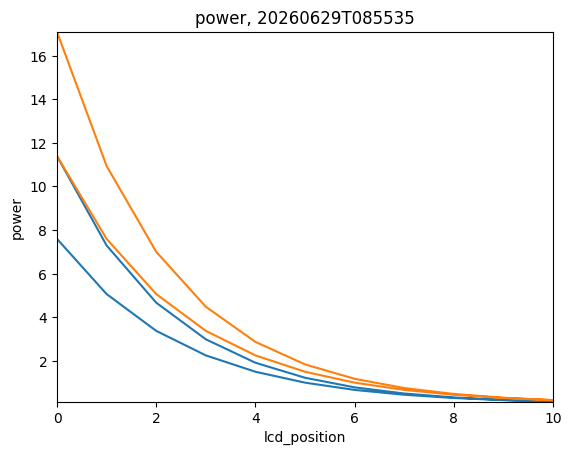

In [6]:
try:
    ps.live_plot1D(expt, data_name="power")
except KeyboardInterrupt:
    expt.stop()

In [ ]:
runinfo = ps.RunInfo()

runinfo.measure_function = measure_power
runinfo.scan0 = ps.PropertyScan({'lcd': np.append(ps.drange(0, 1, 10), ps.drange(10, -1, 0))}, prop='position')
runinfo.scan1 = ps.RepeatScan(2)

expt = ps.Experiment(runinfo, devices)
expt.start_thread()

p_f: 0.0
p_r: 0.0
c_o: 0
x: 0.0
p_f: 1.0
p_r: 1.0
c_o: 0
x: 1.0
p_f: 2.0
p_r: 2.0
c_o: 0
x: 2.0
p_f: 3.0
p_r: 3.0
c_o: 0
x: 3.0
p_f: 4.0
p_r: 4.0
c_o: 0
x: 4.0
p_f: 5.0
p_r: 5.0
c_o: 0
x: 5.0
p_f: 6.0
p_r: 6.0
c_o: 0
x: 6.0
p_f: 7.0
p_r: 7.0
c_o: 0
x: 7.0
p_f: 8.0
p_r: 8.0
c_o: 0
x: 8.0
p_f: 9.0
p_r: 9.0
c_o: 0
x: 9.0
p_f: 10.0
p_r: 10.0
c_o: 0
x: 10.0
p_f: 10.0
p_r: 10.0
c_o: 0
x: 10.0
p_f: 9.0
p_r: 9.1
c_o: -0.1
x: 9.0
p_f: 8.0
p_r: 8.2
c_o: -0.2
x: 8.0
p_f: 7.0
p_r: 7.3
c_o: -0.29999999999999993
x: 7.000000000000001
p_f: 6.0
p_r: 6.3999999999999995
c_o: -0.3999999999999999
x: 6.000000000000001
p_f: 5.0
p_r: 5.499999999999999
c_o: -0.4999999999999999
x: 5.000000000000001
p_f: 4.0
p_r: 4.6
c_o: -0.5999999999999999
x: 4.000000000000002
p_f: 3.0
p_r: 3.6999999999999997
c_o: -0.6999999999999998
x: 3.0000000000000018
p_f: 2.0
p_r: 2.8
c_o: -0.7999999999999998
x: 2.0000000000000018
p_f: 1.0
p_r: 1.9
c_o: -0.8999999999999998
x: 1.0000000000000018
p_f: 0.0
p_r: 0.9999999999999999
c_o: -0.999

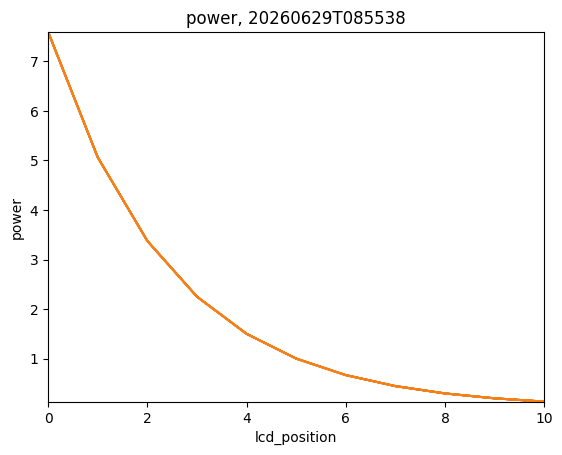

In [8]:
try:
    ps.live_plot1D(expt, data_name="power")
except KeyboardInterrupt:
    expt.stop()